# UK Crime Data – Exploratory Data Analysis
**Project:** UK Crime Data EDA  
**Author:** Adam Choy

**Date:** 14th March 2026

**Dataset:** UK Street-Level Crime: https://data.police.uk/data/ <br>
<br>**Additional Data:** <br>
LSOA Population: https://www.gov.uk/government/news/uk-house-price-index-for-december-2025 <br>
LSOA House Prices: https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/medianpricepaidbylowerlayersuperoutputareahpssadataset46

**Police Forces:** Metropolitan Police, Thames Valley, West Midlands, West Yorkshire 

**Time Period:** 2 Years, 1st February 2024 - 31st January 2026

**Steps:**
1. Import Libraries

2. Load Data into Python <br>

3. General Crime Overview

4. Temporal Crime Analysis <br>

5. Geograpic Crime Analysis

6. House Price Analysis <br>

7. Findings

**Note:** In the interest of honesty, generative AI tools were extensively to fine-tune the graphs presented in this report. However, all analytical direction was led independently
   


## 1. Import Libraries
Import all necessary libraries required for data visualisation.

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gdp
import os

## 2. Load Clean Data into Notebook

In [187]:
# Create output folder for charts
os.makedirs("charts", exist_ok=True)

In [188]:
# Load clean dataset from pre-processing notebook
df = pd.read_csv(os.path.join("UK_Crime_Data", "UK_Crime_Clean.csv"))

print(df.shape)
df.head()

(3685410, 12)


,Crime ID,Falls within,Longitude,Latitude,LSOA code,LSOA name,Crime type,Population,House Price,Crime category,Year,Month number
0,19064acc790fb6125fcde7652fd54c0bca0952ec0ab375...,Metropolitan Police Service,0.694489,51.071719,E01024024,Ashford 013E,Drugs,2215.0,422500,Drug Related,2024,2
1,e936c02a9b2af63a455a83c518543f1debbacb6d15456e...,Metropolitan Police Service,0.867904,52.028241,E01029875,Babergh 009A,Violence and sexual offences,2433.0,412500,Violent Crime,2024,2
2,ASB-NO-ID,Metropolitan Police Service,0.142112,51.589389,E01000027,Barking and Dagenham 001A,Anti-social behaviour,2188.0,425000,Anti-Social,2024,2
3,ASB-NO-ID,Metropolitan Police Service,0.138830,51.583433,E01000027,Barking and Dagenham 001A,Anti-social behaviour,2188.0,425000,Anti-Social,2024,2
4,ASB-NO-ID,Metropolitan Police Service,0.138781,51.589468,E01000027,Barking and Dagenham 001A,Anti-social behaviour,2188.0,425000,Anti-Social,2024,2


Data has correctly been loaded in so analysis can begin.

## 3. Crime Overview
This section presents an overview of crime in the four selected regions.<br>
The first chart looks at the distribution of crime across the four regions.

**3.1 Total Crime Distribution by Police Force**

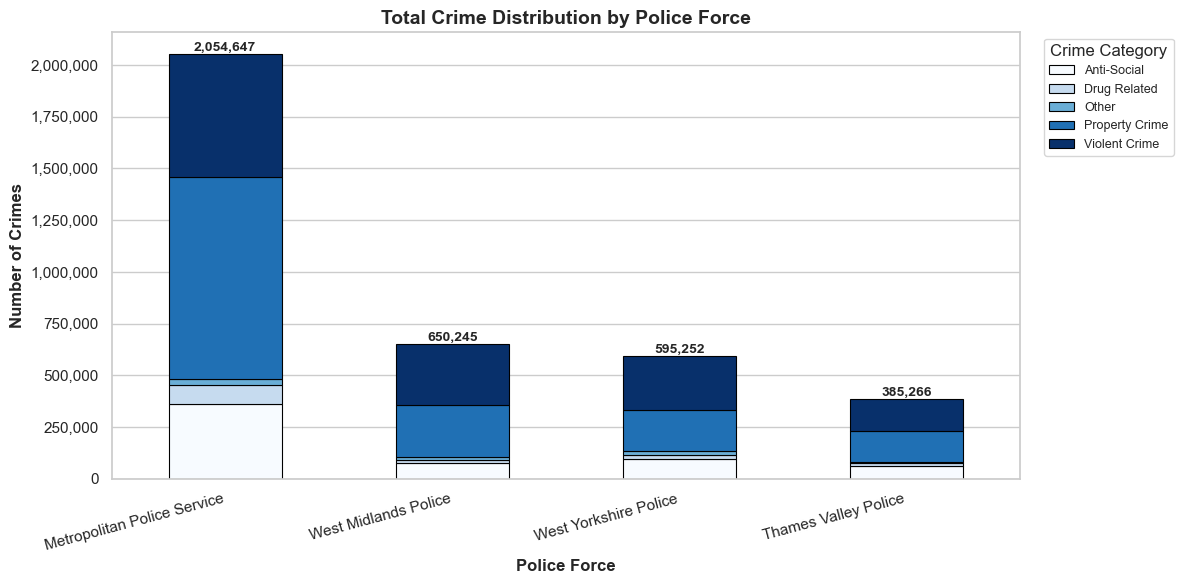

In [195]:
#Chart 3.1 Total crimes by force and crime type
crime_force_type = (
    df.groupby(["Falls within", "Crime category"])
    .size()
    .reset_index(name="Count")
)

# Pivot for stacked bar chart
pivot_df = crime_force_type.pivot(
    index="Falls within",
    columns="Crime category",
    values="Count"
).fillna(0)

# Sort forces by total crimes (descending)
pivot_df["Total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values("Total", ascending=False)
pivot_df = pivot_df.drop(columns="Total")

# Plot stacked bar chart
ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Blues",
    edgecolor="black",
    linewidth=0.8
)

# Add total labels on top of each bar
for bar in ax.patches:
    # Only label the top segment of each stacked bar
    pass

# Calculate totals and add labels manually
totals = pivot_df.sum(axis=1)
for i, (force, total) in enumerate(totals.items()):
    ax.text(
        i,
        total + 500,
        f"{total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Total Crime Distribution by Police Force", fontsize=14, fontweight="bold")
ax.set_xlabel("Police Force", fontweight="bold")
ax.set_ylabel("Number of Crimes", fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Crime Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=15, ha="right")
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("charts/01_crime_distribution_by_police_force.png", dpi=200, bbox_inches="tight")
plt.show()

London reports more street crime than the other three regions put together, at 2.05 million since 2024. However, this is to be expected as London also has a far greater population than the other regions. The proportion of types of crime committed are fairly similar in all regions, except Property Crime and Anti-Social crime in London.

**3.2 Crime Rate per Force**

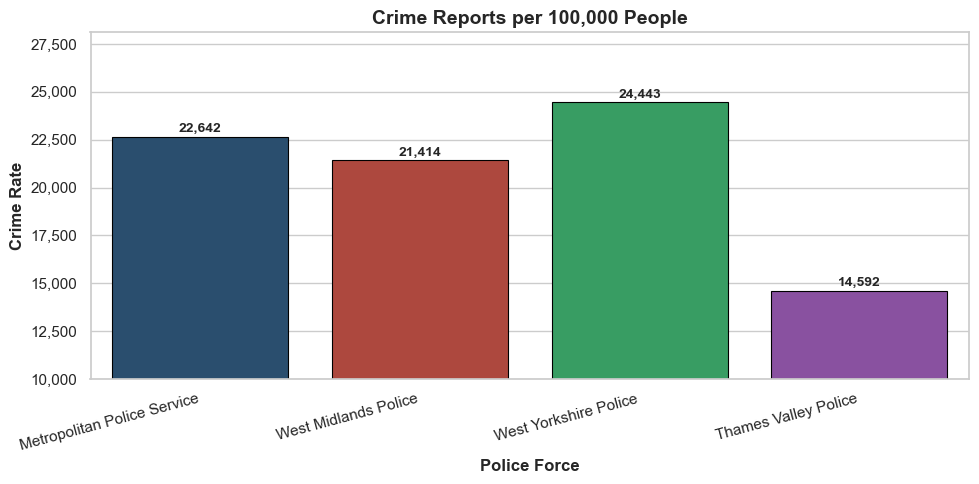

In [196]:
# ── Chart 3.2: Crime Rate per Force ──
population_data = {
    "Metropolitan Police Service": 9_074_625,
    "Thames Valley Police":        2_640_201,
    "West Midlands Police":        3_036_605,
    "West Yorkshire Police":       2_435_236,
}

force_pop = pd.DataFrame(
    list(population_data.items()),
    columns=["Force", "Population"]
)

force_summary = force_counts.merge(force_pop, on="Force", how="left")
force_summary["Crime Rate per 100k"] = (
    force_summary["Total Crimes"] / force_summary["Population"] * 100_000
).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=force_summary, x="Force", y="Crime Rate per 100k",
            palette=colors, edgecolor="black", linewidth=0.8, ax=ax)
ax.set_title("Crime Reports per 100,000 People", fontsize=14, fontweight="bold")
ax.set_xlabel("Police Force", fontweight="bold")
ax.set_ylabel("Crime Rate", fontweight="bold")
ax.set_ylim(10000, force_summary["Crime Rate per 100k"].max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 250,
            f"{bar.get_height():,.0f}", ha="center", fontsize=10, fontweight="bold")
ax.xaxis.grid(False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("charts/02_crime_rate_per_100k.png", dpi=150, bbox_inches="tight")
plt.show()

This chart gives a true reflection of the amount of crime in each region. West Yorkshire has the highest crime rate and Metropolitan has the lowest, confirming the need to standardise crime by population. Next, the most common types of crime in all four regions will be investigated.

**3.3 Top 5 Most Common Types of Crime**

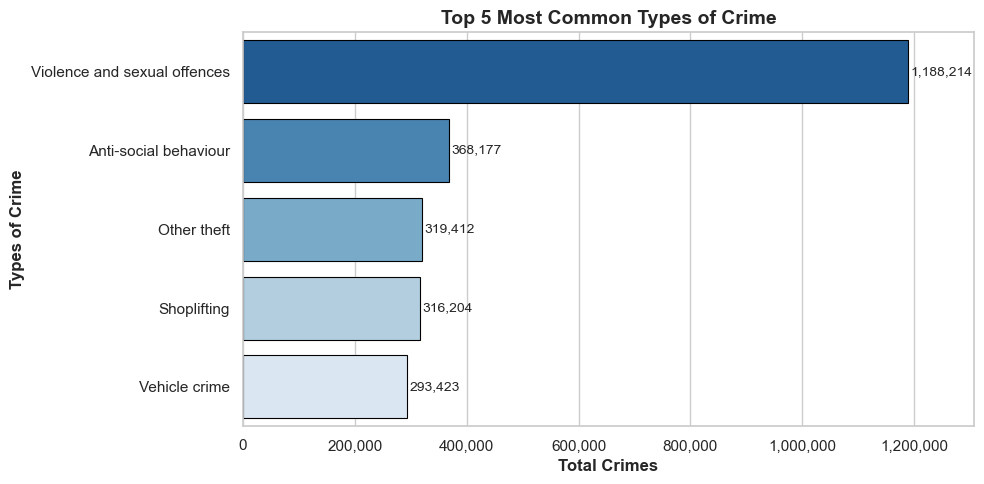

In [197]:
# ── Chart 3.3: Top 5 Most Common Crime Types ──
top5 = df["Crime type"].value_counts().head(5).reset_index()
top5.columns = ["Crime Type", "Count"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top5, x="Count", y="Crime Type",
            palette="Blues_r", edgecolor="black", linewidth=0.8, ax=ax)
ax.set_title("Top 5 Most Common Types of Crime", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Crimes",fontweight="bold")
ax.set_ylabel("Types of Crime", fontweight="bold")
ax.set_xlim(0, top5["Count"].max() * 1.1)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar in ax.patches:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():,.0f}", va="center", fontsize=10)
ax.yaxis.grid(False)
plt.tight_layout()
plt.savefig("charts/03_top5_crime_types.png", dpi=150, bbox_inches="tight")
plt.show()

In [198]:
# Create combined date column
df["Date"] = pd.to_datetime(
    df[["Year", "Month number"]].rename(
        columns={"Year": "year", "Month number": "month"}
    ).assign(day=1)
)

# Population aggregated to force level for crime rate
pop_by_force = (
    df.groupby("Falls within")["Population"]
    .first()
    .reset_index()
)
pop_by_force.columns = ["Force", "Population"]
print(pop_by_force)

                         Force  Population
0  Metropolitan Police Service      2215.0
1         Thames Valley Police      1485.0
2         West Midlands Police      1554.0
3        West Yorkshire Police      1690.0


**3.4 Crime Category Share by Police Force**

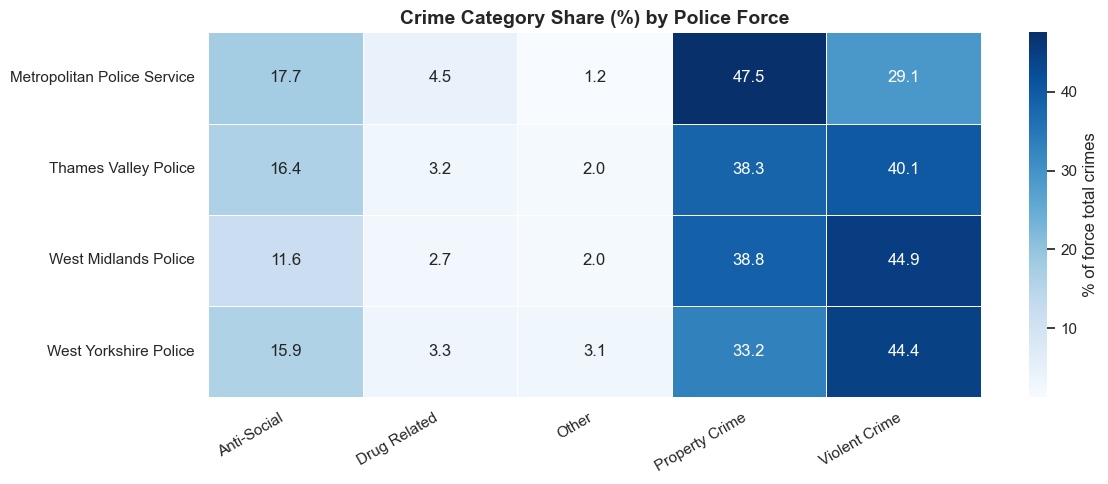

In [200]:
# Chart 3.4 - Crime Category Heatmap by Force
pivot = df.groupby(["Falls within", "Crime category"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "% of force total crimes"}, ax=ax)
ax.set_title("Crime Category Share (%) by Police Force",
             fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("charts/4_crime_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**3.5 Top 10 LSOA Areas for Burglary Reports**

       LSOA name                Falls within  Burglaries
Westminster 013G Metropolitan Police Service         485
      Leeds 111B       West Yorkshire Police         473
Westminster 013B Metropolitan Police Service         285
Westminster 018A Metropolitan Police Service         250
 Birmingham 138A        West Midlands Police         247
Westminster 013D Metropolitan Police Service         235
   Bradford 065C       West Yorkshire Police         229
    Hackney 033C Metropolitan Police Service         202
Westminster 011B Metropolitan Police Service         190
Westminster 018B Metropolitan Police Service         182


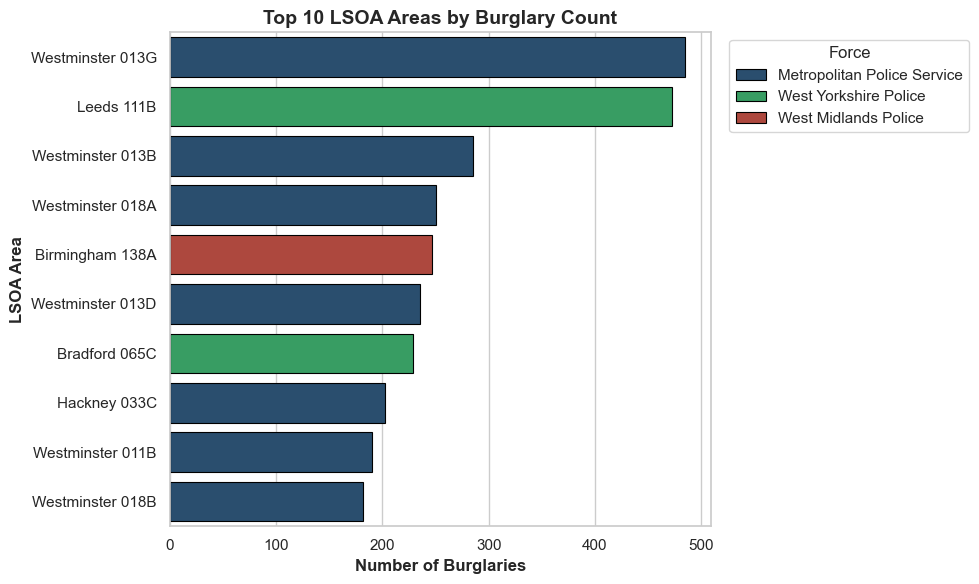

In [201]:
# Chart 3.5 ── Top 10 LSOA Hotspots for Burglary ──

# Filter burglary only, remove unknown LSOAs
burglary = df[
    (df["Crime type"] == "Burglary") &
    (df["LSOA name"].notna()) &
    (df["LSOA name"] != "Unknown")
]

# Top 10 LSOAs by burglary count
burglary_counts = (
    burglary.groupby(["LSOA name", "Falls within"])
    .size()
    .reset_index(name="Burglaries")
    .nlargest(10, "Burglaries")
)

print(burglary_counts.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=burglary_counts, x="Burglaries", y="LSOA name",
            hue="Falls within", dodge=False,
            palette=force_color_map, edgecolor="black", linewidth=0.8, ax=ax)

ax.set_title("Top 10 LSOA Areas by Burglary Count",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Burglaries", fontweight="bold")
ax.set_ylabel("LSOA Area", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Force", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.yaxis.grid(False)
plt.tight_layout()
plt.savefig("charts/5_top10_burglary_lsoa.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Temporal Trends
This section investigates how crime has changed over the past 2 years. It also looks at how crime changes over the course over the year.

**4.1 Monthly Crime Rate per Police Force**

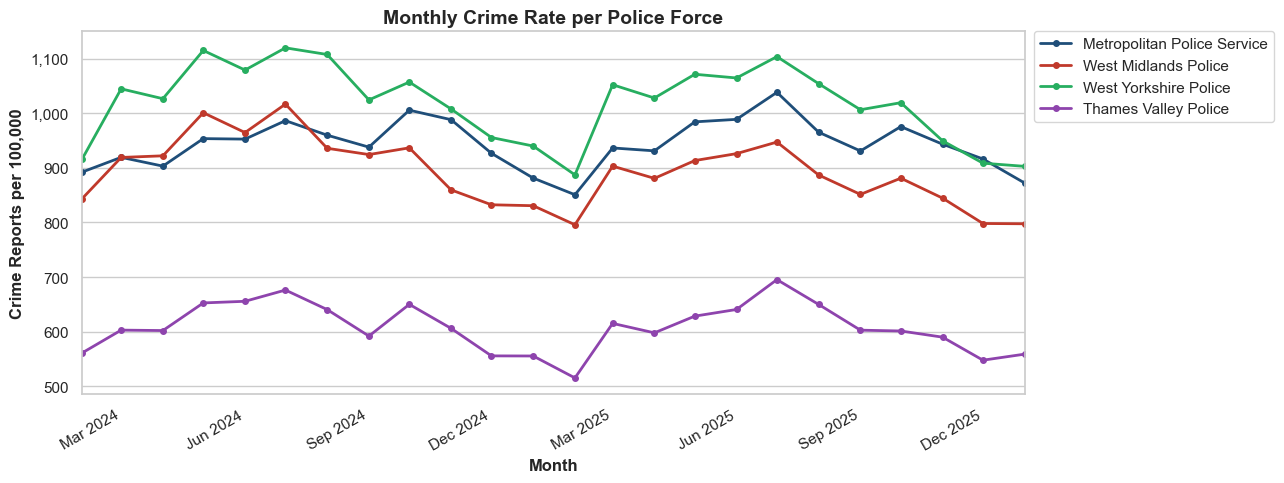

In [202]:
# ── Chart :4.1 Crime Rate Over Time per Force ──
import matplotlib.dates as mdates

# Create combined date column
df["Date"] = pd.to_datetime(
    df[["Year", "Month number"]].rename(
        columns={"Year": "year", "Month number": "month"}
    ).assign(day=1)
)
monthly_rate = monthly.merge(force_summary[["Force", "Population"]],
                              left_on="Falls within", right_on="Force", how="left")
monthly_rate["Crime Rate per 100k"] = (
    monthly_rate["Total Crimes"] / monthly_rate["Population"] * 100_000
).round(1)

fig, ax = plt.subplots(figsize=(13, 5))
for force, color in zip(forces, colors):
    data = monthly_rate[monthly_rate["Falls within"] == force].sort_values("Date")
    ax.plot(data["Date"], data["Crime Rate per 100k"], marker="o", markersize=4,
            linewidth=2, label=force, color=color)
ax.set_title("Monthly Crime Rate per Police Force", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Crime Reports per 100,000", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
ax.set_xlim(pd.Timestamp("2024-02-01"), monthly_rate["Date"].max())
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
ax.xaxis.grid(False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/06_crime_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

**4.2 Seasonal Crime**

In [ ]:
# ── Chart 4.2: Seasonality — Average Crimes by Month of Year ──
seasonal = df.groupby("Month number").size().reset_index(name="Total Crimes")
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=seasonal, x="Month number", y="Total Crimes",
            palette="Blues_d", edgecolor="black", linewidth=0.8, ax=ax)
ax.set_title("Seasonal Crime", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Total Crimes", fontweight="bold")

# Set y-axis start at 200,000
ax.set_ylim(200000, seasonal["Total Crimes"].max())

ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.grid(False)
plt.tight_layout()
plt.savefig("charts/07_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

**4.3 Year-on-Year Crime Change (not included in EDA)**

Year                 Falls within    2024     2025  Change  % Change
0     Metropolitan Police Service  946150  1029347   83197       8.8
1            Thames Valley Police  179379   191133   11754       6.6
2            West Midlands Police  308409   317615    9206       3.0
3           West Yorkshire Police  278945   294322   15377       5.5


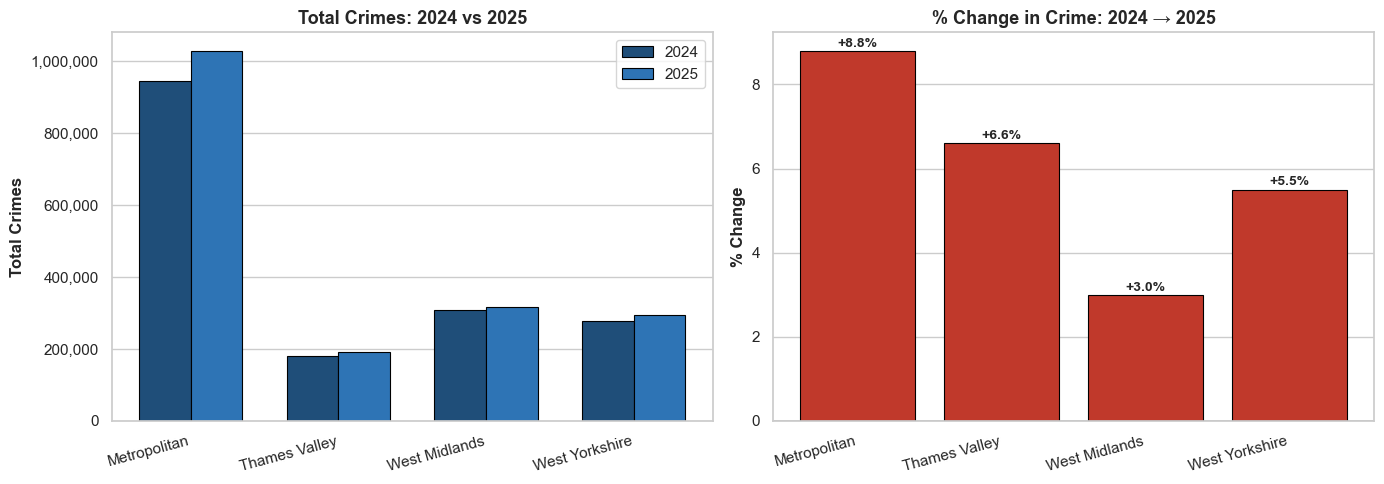


Year-on-Year Summary:
               Falls within   2024    2025  Change  % Change
Metropolitan Police Service 946150 1029347   83197       8.8
       Thames Valley Police 179379  191133   11754       6.6
       West Midlands Police 308409  317615    9206       3.0
      West Yorkshire Police 278945  294322   15377       5.5


In [193]:
# Chart 4.3 ── Year-on-Year Crime Change by Police Force ──
yoy = df[df["Year"] != 2026].groupby(["Falls within", "Year"]).size().reset_index(name="Total Crimes")

yoy_pivot = yoy.pivot(index="Falls within", columns="Year", values="Total Crimes").reset_index()
yoy_pivot["Change"] = yoy_pivot[2025] - yoy_pivot[2024]
yoy_pivot["% Change"] = ((yoy_pivot[2025] - yoy_pivot[2024]) / yoy_pivot[2024] * 100).round(1)

print(yoy_pivot)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Side by side bar chart ──
x = range(len(yoy_pivot))
width = 0.35

axes[0].bar([i - width/2 for i in x], yoy_pivot[2024],
            width, label="2024", color="#1F4E79", edgecolor="black", linewidth=0.8)
axes[0].bar([i + width/2 for i in x], yoy_pivot[2025],
            width, label="2025", color="#2E74B5", edgecolor="black", linewidth=0.8)

axes[0].set_title("Total Crimes: 2024 vs 2025", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Total Crimes", fontweight="bold")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(
    yoy_pivot["Falls within"].str.replace(" Police Service", "").str.replace(" Police", ""),
    rotation=15, ha="right"
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].legend()
axes[0].xaxis.grid(False)

# ── Right: % change bar chart ──
colors_change = ["#C0392B" if v > 0 else "#27AE60" for v in yoy_pivot["% Change"]]
bars = axes[1].bar(
    yoy_pivot["Falls within"].str.replace(" Police Service", "").str.replace(" Police", ""),
    yoy_pivot["% Change"],
    color=colors_change, edgecolor="black", linewidth=0.8
)
axes[1].axhline(y=0, color="black", linewidth=1)
axes[1].set_title("% Change in Crime: 2024 → 2025", fontsize=13, fontweight="bold")
axes[1].set_ylabel("% Change", fontweight="bold")
axes[1].xaxis.grid(False)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha="right")

# Add value labels
for bar, val in zip(bars, yoy_pivot["% Change"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:+.1f}%",
        ha="center", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.savefig("charts/8_yoy_crime_change.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary
print("\nYear-on-Year Summary:")
print(yoy_pivot[["Falls within", 2024, 2025, "Change", "% Change"]].to_string(index=False))

## 5. Geographic Crime Analysis

**5.1 Crime Reports across England**

In [ ]:
import geopandas as gpd
# Chart 5.1 ── Crime Map
# City coordinates
cities = {
    "London":     (51.509, -0.118),
    "Birmingham": (52.480, -1.890),
    "Leeds":      (53.800, -1.549),
    "Reading":    (51.454, -0.978)
}

# Load UK boundary
url = "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Countries_December_2023_Boundaries_UK_BUC/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
uk = gpd.read_file(url)

# ── Chart 7: Crime locations by force on UK map ──
fig, ax = plt.subplots(figsize=(10, 12))
uk.plot(ax=ax, color="#F5F5F5", edgecolor="#AAAAAA", linewidth=1)

for force, color in zip(forces, colors):
    data = df[df["Falls within"] == force].dropna(subset=["Latitude", "Longitude"])
    ax.scatter(data["Longitude"], data["Latitude"],
               c=color, alpha=0.5, s=0.5, label=force, rasterized=True)

# Add city markers
for city, (lat, lon) in cities.items():
    ax.scatter(lon, lat, c="black", s=80, zorder=5, marker="o")
    ax.annotate(city, (lon, lat),
                textcoords="offset points", xytext=(6, 4),
                fontsize=9, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.set_title("Crime Locations by Police Force", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude", fontweight="bold")
ax.set_ylabel("Latitude", fontweight="bold")
ax.set_xlim(-6, 2)
ax.set_ylim(49.5, 56)
ax.legend(loc="upper right", markerscale=10, framealpha=1)
plt.tight_layout()
plt.savefig("charts/09_crime_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. House Price Analysis
This section explores the effect of crime on house prices across the four regions. 

**6.1 Median House Price by Police Force Region**

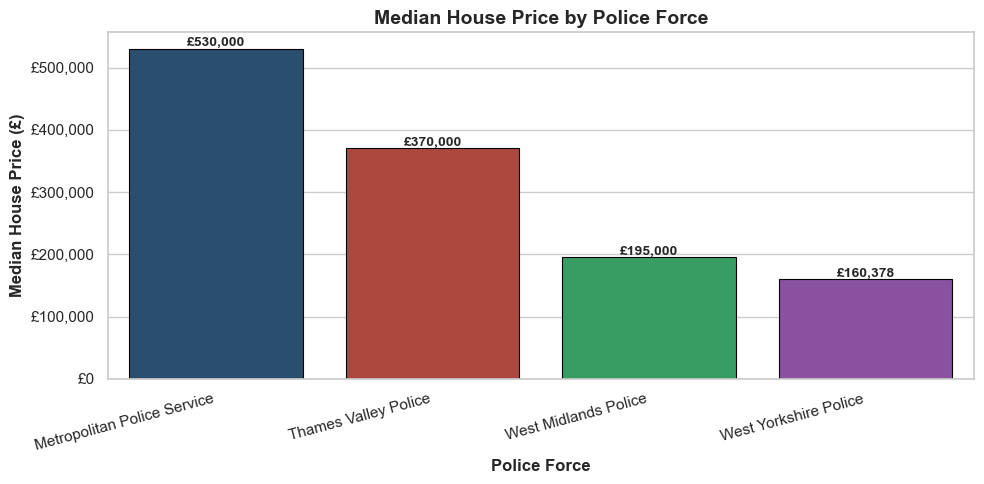

In [191]:
# Chart 6.1 ── Median House Price by Police Force ──
df["House Price"] = pd.to_numeric(df["House Price"], errors="coerce")
median_prices = (
    df.groupby("Falls within")["House Price"]
    .median()
    .reset_index()
    .sort_values("House Price", ascending=False)
)
median_prices.columns = ["Force", "Median House Price"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=median_prices, x="Force", y="Median House Price",
            palette=colors, edgecolor="black", linewidth=0.8, ax=ax)
ax.set_title("Median House Price by Police Force", fontsize=14, fontweight="bold")
ax.set_xlabel("Police Force", fontweight="bold")
ax.set_ylabel("Median House Price (£)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4000,
            f"£{bar.get_height():,.0f}", ha="center", fontsize=10, fontweight="bold")
ax.xaxis.grid(False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("charts/10_median_house_price.png", dpi=150, bbox_inches="tight")
plt.show()

**6.2 House Price by LSOA vs Crime Rate by LSOA**

LSOAs included: 8,330


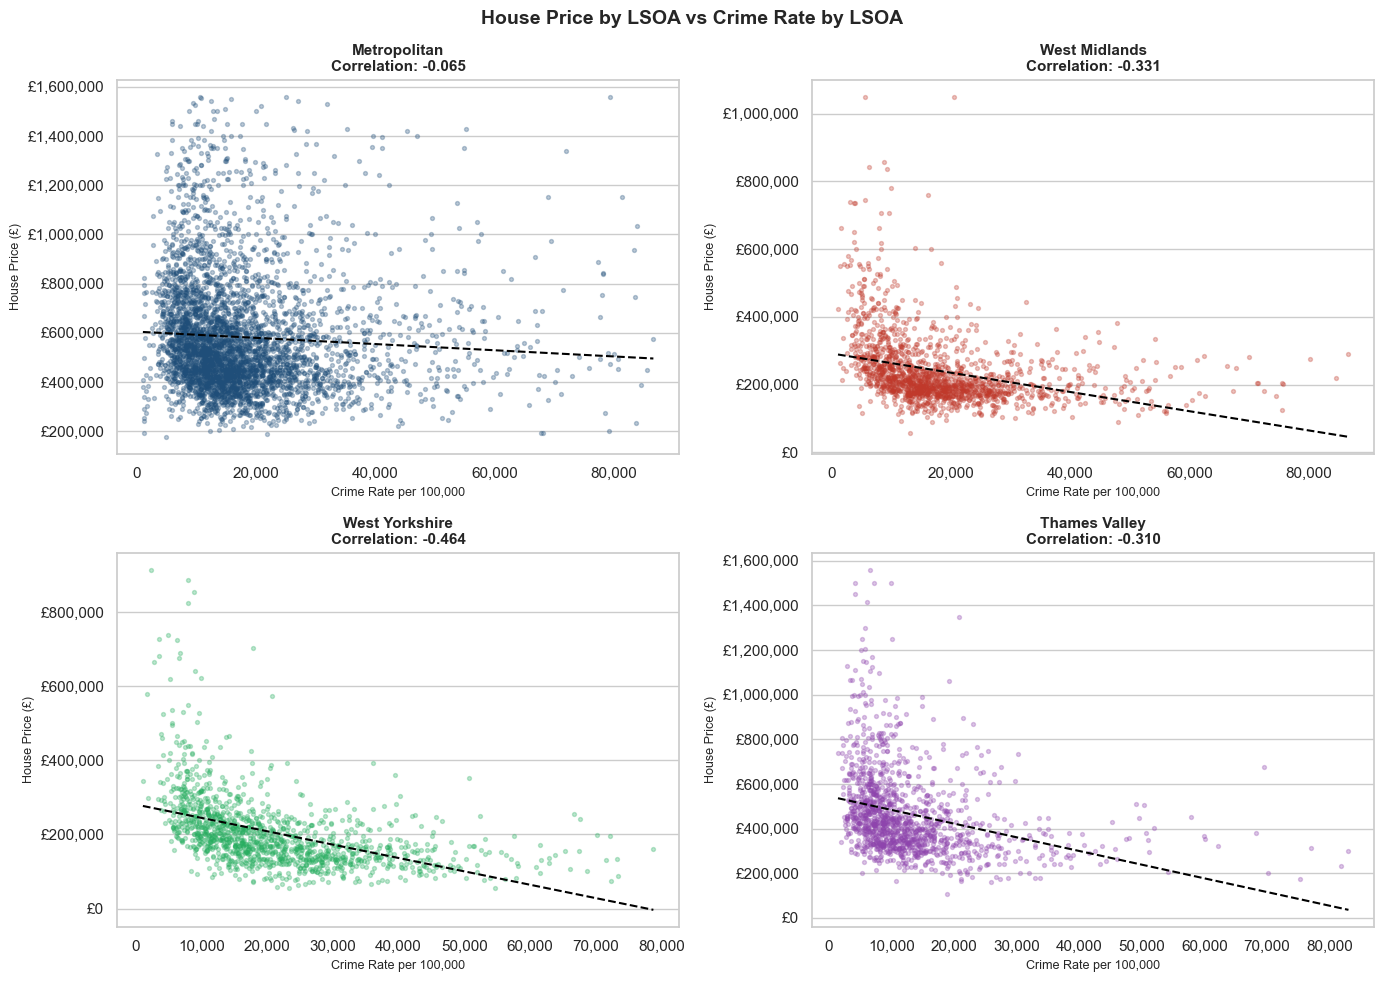


Correlation between Crime Rate per 100k and House Price by Force:
------------------------------------------------------------
Metropolitan Police Service         r = -0.065  ↓ Higher crime = lower price
West Midlands Police                r = -0.331  ↓ Higher crime = lower price
West Yorkshire Police               r = -0.464  ↓ Higher crime = lower price
Thames Valley Police                r = -0.310  ↓ Higher crime = lower price


In [192]:
# Chart 6.2 ── House Price vs Crime Rate by LSOA ──

# Aggregate to LSOA level
lsoa_analysis = (
    df.groupby(["LSOA code", "LSOA name", "Falls within"])
    .agg(
        Total_Crimes = ("Crime ID",    "count"),
        House_Price  = ("House Price", "mean"),
        Population   = ("Population",  "mean")
    )
    .reset_index()
)

# Calculate crime rate per 100k
lsoa_analysis["Crime Rate per 100k"] = (
    lsoa_analysis["Total_Crimes"] / lsoa_analysis["Population"] * 100_000
).round(1)

# Remove nulls, zeros and outliers
lsoa_analysis = lsoa_analysis[
    (lsoa_analysis["House_Price"] > 0) &
    (lsoa_analysis["Crime Rate per 100k"] > 1000) &
    (lsoa_analysis["House_Price"] < lsoa_analysis["House_Price"].quantile(0.99)) &
    (lsoa_analysis["Crime Rate per 100k"] < lsoa_analysis["Crime Rate per 100k"].quantile(0.99))
].dropna(subset=["House_Price", "Crime Rate per 100k"])

print(f"LSOAs included: {len(lsoa_analysis):,}")

forces = lsoa_analysis["Falls within"].unique()
colors = ["#1F4E79", "#C0392B", "#27AE60", "#8E44AD"]
force_color_map = dict(zip(forces, colors))

# ── Plot 2: Faceted — one panel per force ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, force, color in zip(axes, forces, colors):
    data = lsoa_analysis[lsoa_analysis["Falls within"] == force]

    ax.scatter(data["Crime Rate per 100k"], data["House_Price"],
               c=color, alpha=0.3, s=8, rasterized=True)

    # Trend line
    x = data["Crime Rate per 100k"]
    y = data["House_Price"]
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), color="black", linewidth=1.5,
            linestyle="--", label="Trend")

    # Correlation
    corr = data["Crime Rate per 100k"].corr(data["House_Price"])
    ax.set_title(
        f"{force.replace(' Police Service','').replace(' Police','')}\n"
        f"Correlation: {corr:.3f}",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Crime Rate per 100,000", fontsize=9)
    ax.set_ylabel("House Price (£)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.xaxis.grid(False)

fig.suptitle("House Price by LSOA vs Crime Rate by LSOA",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/11_house_price_vs_crime_rate_faceted.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Correlation summary ──
print("\nCorrelation between Crime Rate per 100k and House Price by Force:")
print("-" * 60)
for force in forces:
    data = lsoa_analysis[lsoa_analysis["Falls within"] == force]
    corr = data["Crime Rate per 100k"].corr(data["House_Price"])
    direction = "↓ Higher crime = lower price" if corr < 0 else "↑ Higher crime = higher price"
    print(f"{force:<35} r = {corr:+.3f}  {direction}")

## 7. Findings

Based on the EDA, the following two police force areas are recommended for deeper investigation in the next stage of the project:

**1: West Yorkshire**
- Strongest crime-price correlation (r = -0.464)
- Highest crime rate per 100k — widest variation between neighbourhoods (LSOAs)
- Lowest house prices — highest growth potential in safe LSOAs

**2: Metropolitan Police Service**
- Richest dataset for neighbourhood-level analysis
- Low correlation (r = -0.065) — crime is not the biggest driver London property prices, what is?
- Enormous LSOA variation creates hidden undervalued opportunities
- Highest property values means it's the most commercially valuable

Further discussion can be found in the EDA report.